In [1]:
# Cell 1 - Generate 1000 Patient Clinical Trial Dataset
import pandas as pd
import numpy as np

np.random.seed(42)
n = 1000

data = {
    'patient_id': ['PT' + str(i).zfill(4) for i in range(1, n+1)],
    'age': np.random.randint(18, 75, n),
    'gender': np.random.choice(['Male', 'Female'], n),
    'site': np.random.choice(['Site_A', 'Site_B', 'Site_C', 'Site_D'], n),
    'treatment_group': np.random.choice(['Drug', 'Placebo'], n),
    'ae_count': np.random.randint(0, 10, n),
    'ae_severity': np.random.choice(['Mild', 'Moderate', 'Severe'], n),
    'sae_flag': np.random.choice([0, 1], n, p=[0.85, 0.15]),
    'visit_count': np.random.randint(1, 12, n),
    'dropout': np.random.choice([0, 1], n, p=[0.75, 0.25])
}

df = pd.DataFrame(data)
df.to_csv('clinical_trial_data.csv', index=False)
print("✅ Dataset created!")
print(df.head())
print(f"\nShape: {df.shape}")

✅ Dataset created!
  patient_id  age  gender    site treatment_group  ae_count ae_severity  \
0     PT0001   56    Male  Site_B            Drug         2        Mild   
1     PT0002   69  Female  Site_C            Drug         7      Severe   
2     PT0003   46    Male  Site_D         Placebo         0      Severe   
3     PT0004   32  Female  Site_C            Drug         9    Moderate   
4     PT0005   60    Male  Site_B         Placebo         3    Moderate   

   sae_flag  visit_count  dropout  
0         0            9        0  
1         0            4        1  
2         0            2        0  
3         1            8        0  
4         0            4        0  

Shape: (1000, 10)


Logistic Regression: 0.8
Random Forest: 0.77


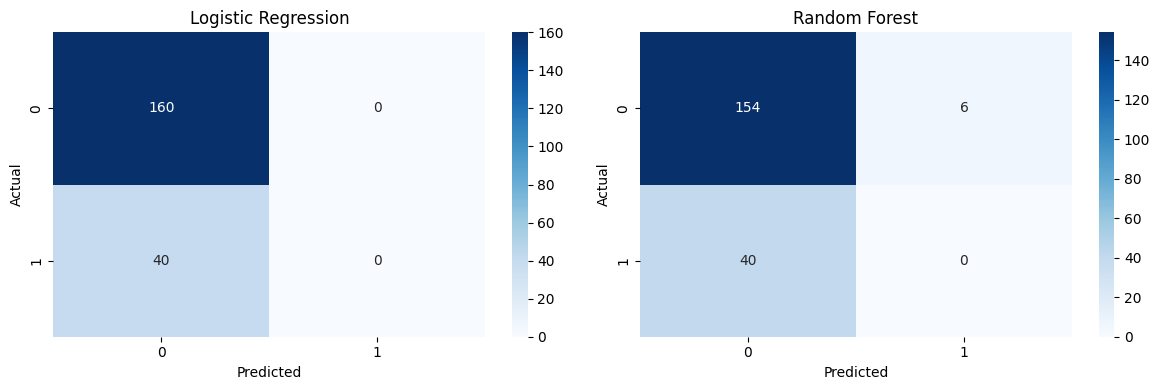

✅ ML Model Complete!


In [2]:
# Cell 2 - Patient Dropout Prediction ML Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
df_ml = df.copy()
le = LabelEncoder()
df_ml['gender'] = le.fit_transform(df_ml['gender'])
df_ml['site'] = le.fit_transform(df_ml['site'])
df_ml['treatment_group'] = le.fit_transform(df_ml['treatment_group'])
df_ml['ae_severity'] = le.fit_transform(df_ml['ae_severity'])

# Features & Target
X = df_ml[['age','gender','site','treatment_group',
           'ae_count','ae_severity','sae_flag','visit_count']]
y = df_ml['dropout']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train 2 Models
lr = LogisticRegression()
rf = RandomForestClassifier(n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Results
print("Logistic Regression:", accuracy_score(y_test, lr.predict(X_test)))
print("Random Forest:", accuracy_score(y_test, rf.predict(X_test)))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, model, name in zip(axes, [lr, rf],
                           ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues')
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print("✅ ML Model Complete!")

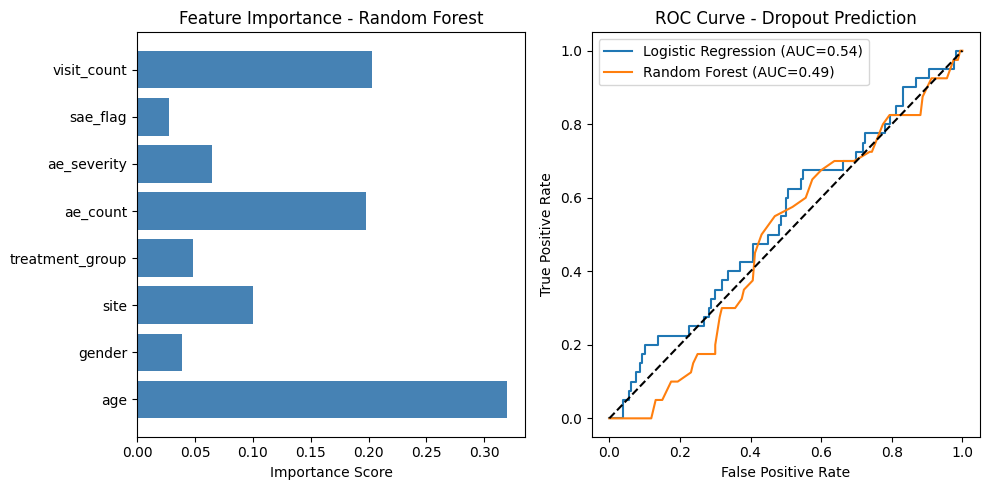

✅ Visualization Complete!


In [3]:
# Cell 3 - Feature Importance & ROC Curve
from sklearn.metrics import roc_curve, auc

# Feature Importance
feature_names = ['age','gender','site','treatment_group',
                 'ae_count','ae_severity','sae_flag','visit_count']
importances = rf.feature_importances_

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.barh(feature_names, importances, color='steelblue')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')

# ROC Curve
plt.subplot(1, 2, 2)
for model, name in [(lr, 'Logistic Regression'),
                    (rf, 'Random Forest')]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr,tpr):.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Dropout Prediction')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()
print("✅ Visualization Complete!")

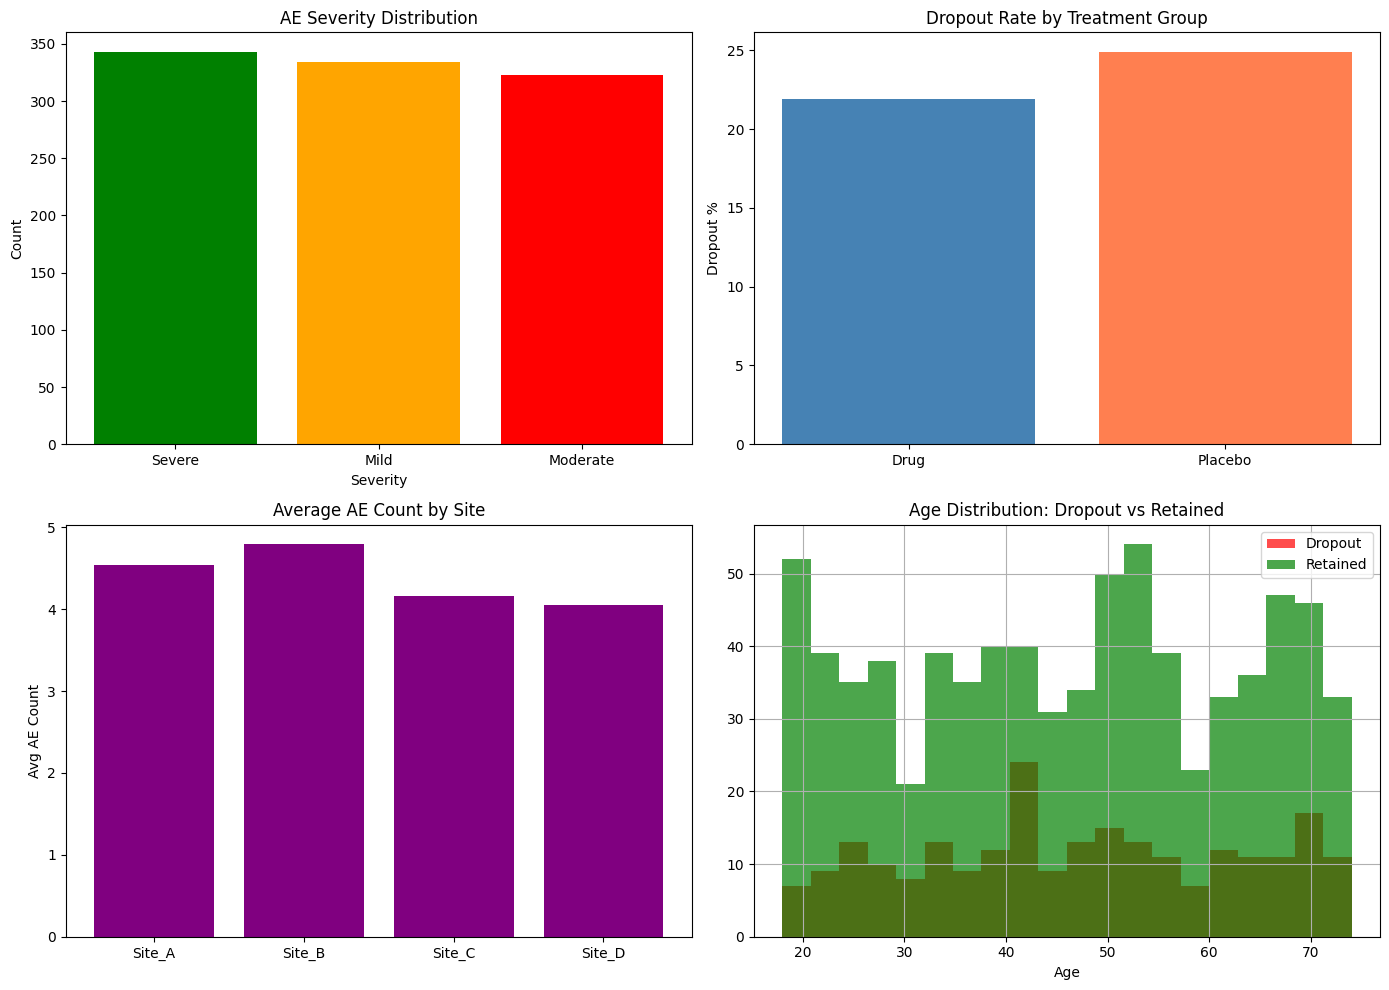

✅ Clinical Analysis Complete!


In [4]:
# Cell 4 - Clinical AE Analysis Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 - AE Severity Distribution
ae_counts = df['ae_severity'].value_counts()
axes[0,0].bar(ae_counts.index, ae_counts.values,
              color=['green','orange','red'])
axes[0,0].set_title('AE Severity Distribution')
axes[0,0].set_xlabel('Severity')
axes[0,0].set_ylabel('Count')

# Chart 2 - Dropout by Treatment Group
dropout_grp = df.groupby('treatment_group')['dropout'].mean()*100
axes[0,1].bar(dropout_grp.index, dropout_grp.values,
              color=['steelblue','coral'])
axes[0,1].set_title('Dropout Rate by Treatment Group')
axes[0,1].set_ylabel('Dropout %')

# Chart 3 - AE Count by Site
site_ae = df.groupby('site')['ae_count'].mean()
axes[1,0].bar(site_ae.index, site_ae.values, color='purple')
axes[1,0].set_title('Average AE Count by Site')
axes[1,0].set_ylabel('Avg AE Count')

# Chart 4 - Age Distribution of Dropouts
df[df['dropout']==1]['age'].hist(bins=20, ax=axes[1,1],
                                  color='red', alpha=0.7)
df[df['dropout']==0]['age'].hist(bins=20, ax=axes[1,1],
                                  color='green', alpha=0.7)
axes[1,1].set_title('Age Distribution: Dropout vs Retained')
axes[1,1].legend(['Dropout','Retained'])
axes[1,1].set_xlabel('Age')

plt.tight_layout()
plt.savefig('clinical_analysis.png')
plt.show()
print("✅ Clinical Analysis Complete!")